<a href="https://colab.research.google.com/github/himadri-lukhi/OIBSIP_DataAnalytics_Level1_Project2/blob/main/customer_segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Customer Segmentation Analysis

The objective of this project is to analyze customer purchasing behavior and segment customers into distinct groups using the K-Means clustering algorithm. The insights obtained from segmentation can help businesses design targeted marketing strategies, improve customer satisfaction, and increase profitability.

In [42]:
# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Ignore Warnings
import warnings
warnings.filterwarnings('ignore')

Data Loading and Cleaning

In [43]:
df = pd.read_excel('ifood.xlsx')

In [44]:
df

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,marital_Together,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall
0,58138,0,0,58,635,88,546,172,88,88,...,0,0,0,0,1,0,0,1529,1441,0
1,46344,1,1,38,11,1,6,2,1,6,...,0,0,0,0,1,0,0,21,15,0
2,71613,0,0,26,426,49,127,111,21,42,...,1,0,0,0,1,0,0,734,692,0
3,26646,1,0,26,11,4,20,10,3,5,...,1,0,0,0,1,0,0,48,43,0
4,58293,1,0,94,173,43,118,46,27,15,...,0,0,0,0,0,0,1,407,392,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2200,61223,0,1,46,709,43,182,42,118,247,...,0,0,0,0,1,0,0,1094,847,0
2201,64014,2,1,56,406,0,30,0,0,8,...,1,0,0,0,0,0,1,436,428,1
2202,56981,0,0,91,908,48,217,32,12,24,...,0,0,0,0,1,0,0,1217,1193,1
2203,69245,0,1,8,428,30,214,80,30,61,...,1,0,0,0,0,1,0,782,721,0


In [45]:
df.head()

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,marital_Together,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall
0,58138,0,0,58,635,88,546,172,88,88,...,0,0,0,0,1,0,0,1529,1441,0
1,46344,1,1,38,11,1,6,2,1,6,...,0,0,0,0,1,0,0,21,15,0
2,71613,0,0,26,426,49,127,111,21,42,...,1,0,0,0,1,0,0,734,692,0
3,26646,1,0,26,11,4,20,10,3,5,...,1,0,0,0,1,0,0,48,43,0
4,58293,1,0,94,173,43,118,46,27,15,...,0,0,0,0,0,0,1,407,392,0


In [46]:
df.shape

(2205, 39)

In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2205 entries, 0 to 2204
Data columns (total 39 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Income                2205 non-null   int64
 1   Kidhome               2205 non-null   int64
 2   Teenhome              2205 non-null   int64
 3   Recency               2205 non-null   int64
 4   MntWines              2205 non-null   int64
 5   MntFruits             2205 non-null   int64
 6   MntMeatProducts       2205 non-null   int64
 7   MntFishProducts       2205 non-null   int64
 8   MntSweetProducts      2205 non-null   int64
 9   MntGoldProds          2205 non-null   int64
 10  NumDealsPurchases     2205 non-null   int64
 11  NumWebPurchases       2205 non-null   int64
 12  NumCatalogPurchases   2205 non-null   int64
 13  NumStorePurchases     2205 non-null   int64
 14  NumWebVisitsMonth     2205 non-null   int64
 15  AcceptedCmp3          2205 non-null   int64
 16  Accept

In [48]:
df.isnull().sum()

,0
Income,0
Kidhome,0
Teenhome,0
Recency,0
MntWines,0
MntFruits,0
MntMeatProducts,0
MntFishProducts,0
MntSweetProducts,0
MntGoldProds,0


In [49]:
df.duplicated().sum()

np.int64(184)

In [50]:
df.describe()

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,marital_Together,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall
count,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,...,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.00000
mean,51622.094785,0.442177,0.506576,49.009070,306.164626,26.403175,165.312018,37.756463,27.128345,44.057143,...,0.257596,0.034467,0.089796,0.024490,0.504762,0.165079,0.215873,562.764626,518.707483,0.29932
std,20713.063826,0.537132,0.544380,28.932111,337.493839,39.784484,217.784507,54.824635,41.130468,51.736211,...,0.437410,0.182467,0.285954,0.154599,0.500091,0.371336,0.411520,575.936911,553.847248,0.68044
min,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,-283.000000,0.00000
25%,35196.000000,0.000000,0.000000,24.000000,24.000000,2.000000,16.000000,3.000000,1.000000,9.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,56.000000,42.000000,0.00000
50%,51287.000000,0.000000,0.000000,49.000000,178.000000,8.000000,68.000000,12.000000,8.000000,25.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,343.000000,288.000000,0.00000
75%,68281.000000,1.000000,1.000000,74.000000,507.000000,33.000000,232.000000,50.000000,34.000000,56.000000,...,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,964.000000,884.000000,0.00000
max,113734.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,262.000000,321.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2491.000000,2458.000000,4.00000


Age Distribution

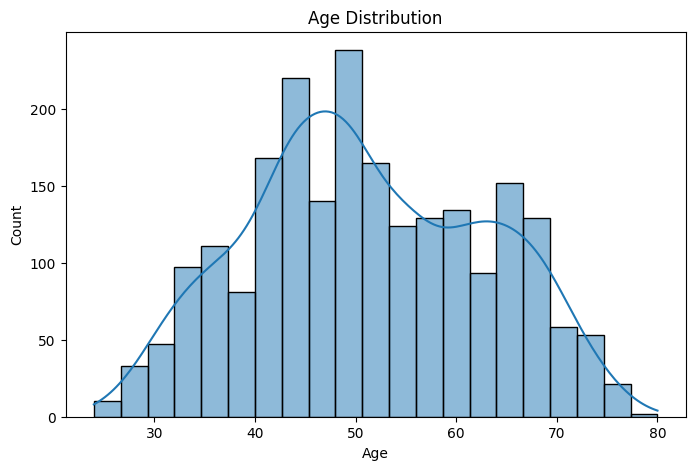

In [51]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], kde=True)
plt.title('Age Distribution')
plt.show()

Income Distribution

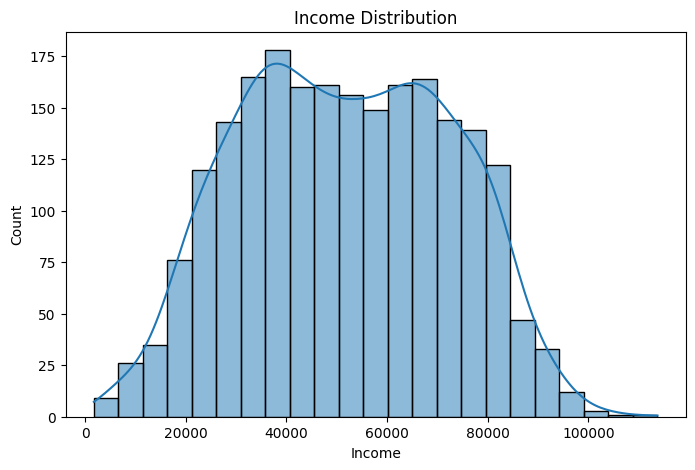

In [52]:
plt.figure(figsize=(8,5))
sns.histplot(df['Income'], kde=True)
plt.title('Income Distribution')
plt.show()

Total Spending Distribution

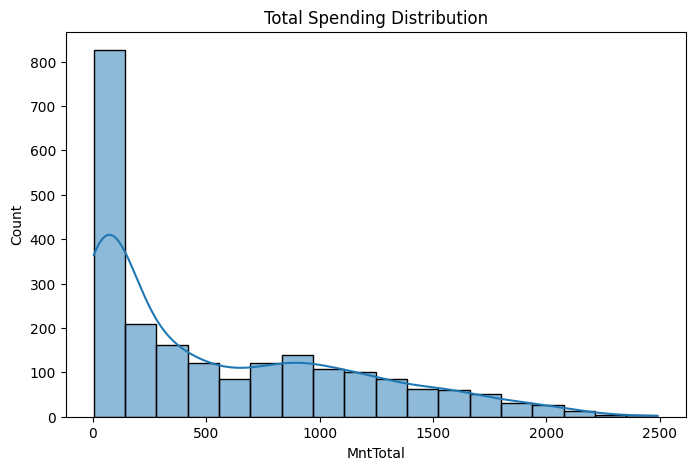

In [53]:
plt.figure(figsize=(8,5))
sns.histplot(df['MntTotal'], kde=True)
plt.title('Total Spending Distribution')
plt.show()

## Feature Selection

The following features were selected for customer segmentation:
- Income
- Total Spending
- Web Purchases
- Catalog Purchases
- Store Purchases
- Age

In [54]:
features = ['Income',
            'MntTotal',
            'NumWebPurchases',
            'NumCatalogPurchases',
            'NumStorePurchases',
            'Age']

X = df[features]

In [55]:
X.head()

,Income,MntTotal,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,Age
0,58138,1529,8,10,4,63
1,46344,21,1,1,2,66
2,71613,734,8,2,10,55
3,26646,48,2,0,4,36
4,58293,407,5,3,6,39


##Feature Scaling

Feature scaling was performed because K-Means clustering is distance-based and sensitive to feature magnitudes.

In [56]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

Elbow Method

In [57]:
wcss = []

for i in range(1,11):
    kmeans = KMeans(
        n_clusters=i,
        random_state=42
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

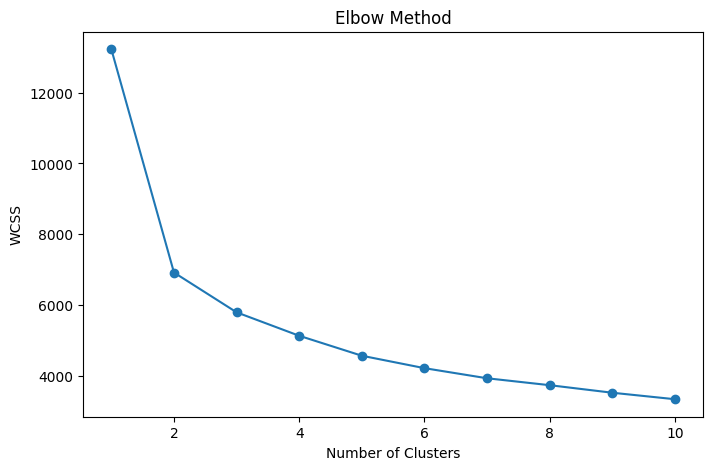

In [58]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')

plt.show()

K-Means Clustering

In [59]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42
)

df['Cluster'] = kmeans.fit_predict(X_scaled)

In [60]:
df['Cluster'].value_counts()

,count
Cluster,
2,651
3,482
1,407
4,337
0,328


Customer Segmentation Visualization

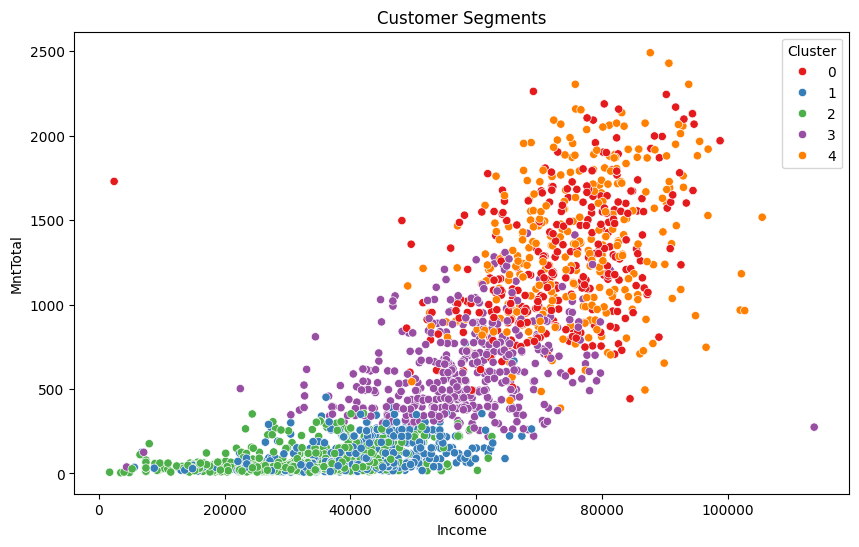

In [61]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='Income',
    y='MntTotal',
    hue='Cluster',
    data=df,
    palette='Set1'
)

plt.title('Customer Segments')
plt.show()

Cluster Distribution

In [62]:
cluster_summary = df.groupby('Cluster')[features].mean()

cluster_summary


,Income,MntTotal,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,Age
Cluster,,,,,,
0,73550.664634,1247.731707,5.243902,6.277439,8.405488,64.039634
1,40580.319410,116.766585,2.292383,0.845209,3.628993,60.823096
2,30928.589862,71.847926,2.078341,0.476190,3.066052,41.715822
3,57404.443983,602.375519,6.767635,2.508299,7.425311,53.574689
4,75318.863501,1326.403561,5.264095,5.670623,8.997033,41.323442


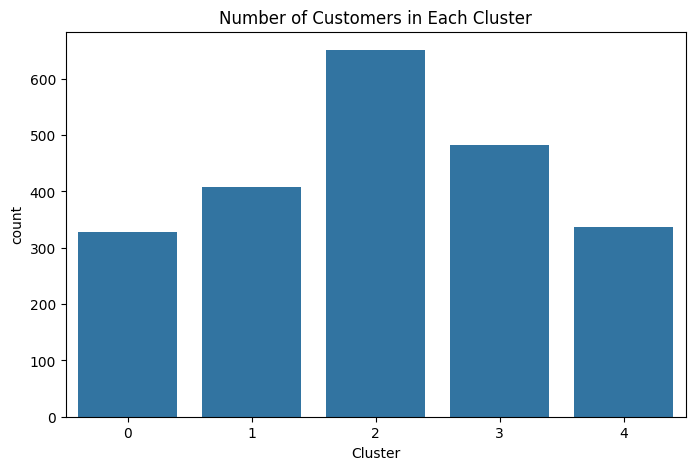

In [63]:
plt.figure(figsize=(8,5))

sns.countplot(x='Cluster', data=df)

plt.title("Number of Customers in Each Cluster")
plt.show()

Average Spending by Cluster

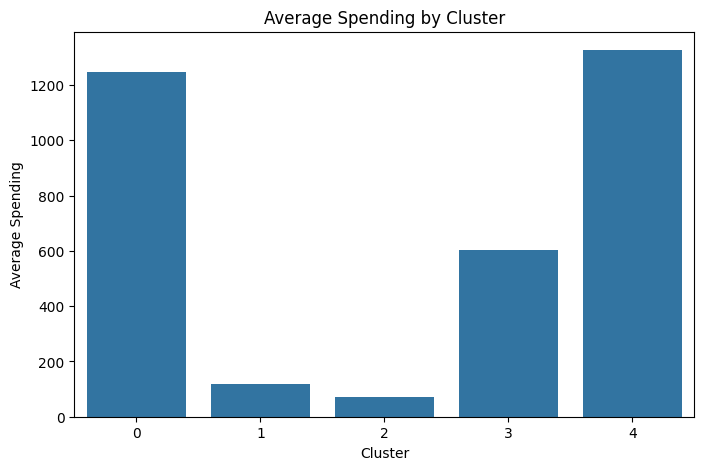

In [64]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=cluster_summary.index,
    y=cluster_summary['MntTotal']
)

plt.title("Average Spending by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Spending")

plt.show()

## Key Insights

1. Five customer segments were identified using K-Means clustering.
2. Cluster 4 represents VIP customers with the highest spending behavior.
3. Cluster 0 consists of premium senior customers with high purchasing power.
4. Cluster 3 contains regular customers with moderate spending.
5. Clusters 1 and 2 are low-value customer groups with lower spending patterns.

## Recommendations

- Offer loyalty rewards to VIP customers.
- Provide premium services to high-income customers.
- Use personalized marketing campaigns for regular customers.
- Introduce discounts and promotional offers for low-value customers.